# 02 — Automated extraction

The pipeline's *Extract* step: collect the publications of the four sources **without
manual intervention**, download the images, and write the whole thing as JSON.

In [1]:
from dotenv import load_dotenv

from multimodal_etl.logging_setup import setup_logging
from multimodal_etl.utils.paths import ROOT_DIR

# No `sys.path` insert: the project is installed in the environment `uv run` provides, and a
# notebook that patches the path hides which interpreter it is actually running against.
load_dotenv(ROOT_DIR / ".env")
setup_logging()

## 1. One source going down must not stop the others

`collect_sources` calls each connector inside its own `try/except` and keeps a tally: the
number of publications per source, `-1` on error. That tally is what feeds the "failed
sources" indicator of the monitoring plan.

In [2]:
from multimodal_etl.config import ExtractionConfig
from multimodal_etl.extract import collect_sources

publications, summary = collect_sources(ExtractionConfig())
print(f"{len(publications)} publications collected")
summary

2026-09-15 13:50:22 | INFO    | multimodal_etl.extract | Extract: starting source 'rss'


2026-09-15 13:50:22 | INFO    | multimodal_etl.sources.rss | RSS: reading feed 'the_guardian' (https://www.theguardian.com/world/rss)


2026-09-15 13:50:22 | INFO    | multimodal_etl.sources.rss | RSS: 45 publications collected from 'the_guardian'


2026-09-15 13:50:22 | INFO    | multimodal_etl.sources.rss | RSS: reading feed 'bbc_news' (https://feeds.bbci.co.uk/news/world/rss.xml)


2026-09-15 13:50:22 | INFO    | multimodal_etl.sources.rss | RSS: 29 publications collected from 'bbc_news'


...

2026-09-15 13:51:02 | INFO    | multimodal_etl.sources.kaggle_fakeddit | Fakeddit: 24 publications loaded from fakeddit_sample.tsv (demonstration sample)


2026-09-15 13:51:02 | INFO    | multimodal_etl.extract | Extract: source 'kaggle_fakeddit' -> 24 publications (ok)


2026-09-15 13:51:02 | INFO    | multimodal_etl.extract | Extract: 171 raw publications in total


171 publications collected


{'rss': {'count': 99, 'cause': 'ok'},
 'newsdata': {'count': 0, 'cause': 'disabled'},
 'fakenewsnet': {'count': 48, 'cause': 'ok'},
 'kaggle_fakeddit': {'count': 24, 'cause': 'ok'}}

## 2. What a connector returns

Every connector produces the **same structure**, whatever the data came from. That is what
lets the next step process them uniformly.

In [3]:
import pandas as pd

raw_frame = pd.DataFrame(publications)
print("Columns:", list(raw_frame.columns))
raw_frame[["source", "source_type", "access_method"]].value_counts().to_frame("publications")

Columns: ['source', 'source_type', 'access_method', 'title', 'text', 'url', 'image_url', 'image_source', 'published_at', 'language', 'label', 'label_source']


,,,publications
source,source_type,access_method,
rss:the_guardian,rss,rss_feed,45
rss:bbc_news,rss,rss_feed,29
rss:abc_news,rss,rss_feed,25
fakenewsnet:politifact,dataset,github_download,24
fakenewsnet:gossipcop,dataset,github_download,24
fakeddit,dataset,kaggle_download,24


## 3. Download the images, not just their URLs

An image URL proves nothing: it can be dead, gated, or point at an HTML page. So the
pipeline **downloads** each image and opens it with Pillow before keeping it. Three
checks, cheapest first: the announced MIME type, the file size, then a real decode.

It is the path of the resulting file that gets recorded next to the text.

In [4]:
from multimodal_etl.config import ImageConfig
from multimodal_etl.images import download_images

counters = download_images(publications, ImageConfig())
counters

2026-09-15 13:52:35 | WARNING | multimodal_etl.images | Image: type 'text/html' rejected for https://web.archive.org/web/20170702174006im_/http://freedomcrossroads.us/wp-con


2026-09-15 13:52:35 | WARNING | multimodal_etl.images | Image: download failed (http://nationalreport.net/wp-content/uploads/2016/05/Target.jpg): 404 Client Error: Not Found for url: https://nationalreport.net/wp-content/uploads/2016/05/Target.jpg


2026-09-15 13:52:37 | WARNING | multimodal_etl.images | Image: type 'text/html' rejected for https://web.archive.org/web/20170731052757im_/http://politicspaper.com/wp-conten


2026-09-15 13:52:45 | INFO    | multimodal_etl.images | Images: 133 downloaded, 3 failures, 35 skipped (10.3 MB on disk)


{'attempted': 136,
 'succeeded': 133,
 'failed': 3,
 'skipped': 35,
 'bytes': 10815530}

In [5]:
with_file = [p for p in publications if p.get("image_path")]
print(f"{len(with_file)} publications now carry an image file")
example = with_file[0]
print("Text: ", example["title"][:88])
print("Image:", example["image_path"])

133 publications now carry an image file
Text:  ‘I believed the hype’: the white South Africans denied refugee status in the US
Image: data/raw/images/51c78d71632bff49.jpg


The text / image pair, shown as it will be handed to the model:

‘I believed the hype’: the white South Africans denied refugee status in the US


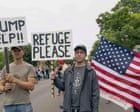

In [6]:
from IPython.display import Image, display

from multimodal_etl.config import absolute_path

print(example["title"])
display(Image(filename=str(absolute_path(example["image_path"])), width=420))

## 4. Saving the raw data

The format chosen is **JSON**, not CSV: a multimodal publication pairs a text with a file
path, and JSON keeps that structure unambiguous. The recorded path is **relative to the
project root**, so it stays valid somewhere other than the machine that produced it — the
pipeline runs locally as well as inside an Airflow container.

In [7]:
import json

from multimodal_etl.extract import save_raw

raw_path = save_raw(publications)
print("Written to:", raw_path)
print(json.dumps(example, ensure_ascii=False, indent=2)[:600])

2026-09-15 13:52:45 | INFO    | multimodal_etl.extract | Extract: 171 publications written to G:\Mon Drive\OC\portfolio\repos\lab-multimodal-etl-airflow\data\raw\raw_publications_20260915_115245.json


Written to: G:\Mon Drive\OC\portfolio\repos\lab-multimodal-etl-airflow\data\raw\raw_publications_20260915_115245.json
{
  "source": "rss:the_guardian",
  "source_type": "rss",
  "access_method": "rss_feed",
  "title": "‘I believed the hype’: the white South Africans denied refugee status in the US",
  "text": "<p>Drive to save thousands of Afrikaners from false claims of ‘white genocide’ appears to show signs of slowing</p><p>When Donald Trump announced in February 2025 that the US would accept Afrikaners from South Africa as refugees, many white South Africans who believed that they were victims of racism in their country thought that their prayers had been answered.</p><p>However, in the past few months, do
